# Week 3 & Week 4 Internship Project

# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1 – Data Loading, Merging & Deep Exploration

### Objective

The objective of this task is to:

- Load the Superstore Sales dataset using Pandas.
- Convert Order Date and Ship Date into datetime format.
- Extract useful time-based features.
- Check data quality (missing values, duplicates, datatypes).
- Aggregate weekly and monthly sales.
- Perform exploratory data analysis.
- Answer business questions using data.

In [2]:
# Import Required Libraries
# Library used for data manipulation
import pandas as pd
# Library used for numerical calculations
import numpy as np
# Library used for plotting graphs
import matplotlib.pyplot as plt
# Library used for attractive statistical plots
import seaborn as sns
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")
# Display plots inside notebook
%matplotlib inline
# Set graph style
plt.style.use("ggplot")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv(r"C:\Users\Akanksha\Downloads\SalesForecasting_Akanksha\train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Check Dataset Shape
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 9800
Number of Columns : 18


### Observation

The dataset contains 9800 rows and 18 columns.

The dataset contains information related to customer orders, products, sales, shipping details and geographical locations.

In [6]:
# Display Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Observation

The dataset contains both numerical and categorical variables.
The Order Date and Ship Date columns are currently stored as object datatype and need to be converted into datetime format.

In [8]:
# Display Column Names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
# Convert Date Columns into Datetime Format
# Convert Order Date
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)
# Convert Ship Date
df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)
print("Date Conversion Completed Successfully")

Date Conversion Completed Successfully


In [10]:
# Verify Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

### Observation

The Order Date and Ship Date columns have been successfully converted into datetime format.

In [12]:
# Create Time-Based Features
# Extract Year
df["Year"] = df["Order Date"].dt.year
# Extract Month Number
df["Month"] = df["Order Date"].dt.month
# Extract Month Name
df["Month Name"] = df["Order Date"].dt.month_name()
# Extract Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week
# Extract Day Name
df["Day"] = df["Order Date"].dt.day_name()
# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Display the new columns
df[["Order Date", "Year", "Month", "Month Name", "Week", "Day", "Quarter"]].head()

,Order Date,Year,Month,Month Name,Week,Day,Quarter
0,2017-11-08,2017,11,November,45,Wednesday,4
1,2017-11-08,2017,11,November,45,Wednesday,4
2,2017-06-12,2017,6,June,24,Monday,2
3,2016-10-11,2016,10,October,41,Tuesday,4
4,2016-10-11,2016,10,October,41,Tuesday,4


In [13]:
# Create Season Feature
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


### Observation

New features such as Year, Month, Week, Quarter, Day and Season were successfully extracted from the Order Date column.

In [15]:
# Check Missing Values
missing_values = df.isnull().sum()
print(missing_values)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week              0
Day               0
Quarter           0
Season            0
dtype: int64


In [16]:
# Check Duplicate Rows
duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [17]:
# Statistical Summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.0,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.0,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.0,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.0,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.0,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


In [18]:
# Aggregate Weekly Sales
weekly_sales = df.groupby("Week")["Sales"].sum()
weekly_sales.head()

Week
1    17108.544
2    15846.432
3    21415.277
4    25545.198
5    29480.100
Name: Sales, dtype: float64

# Business Question 1
## Which Product Category Generates the Highest Total Revenue?
This analysis identifies the product category contributing the highest sales revenue.

In [20]:
# Category Wise Revenue
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


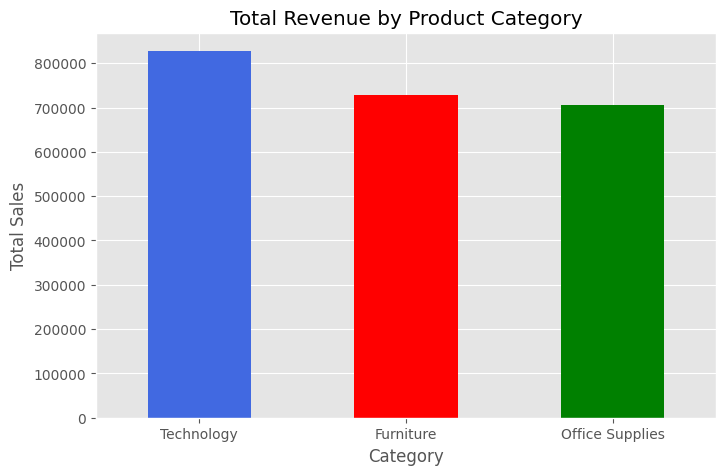

In [21]:
# Category Wise Revenue Chart
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["royalblue","red","green"]
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

### Observation

The product category with the highest total revenue is technology with 800000 total sales.

This category contributes the largest share of overall company sales.

# Business Question 2

## Which Region Has the Most Consistent Sales Growth?

In [24]:
# Region Wise Sales
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


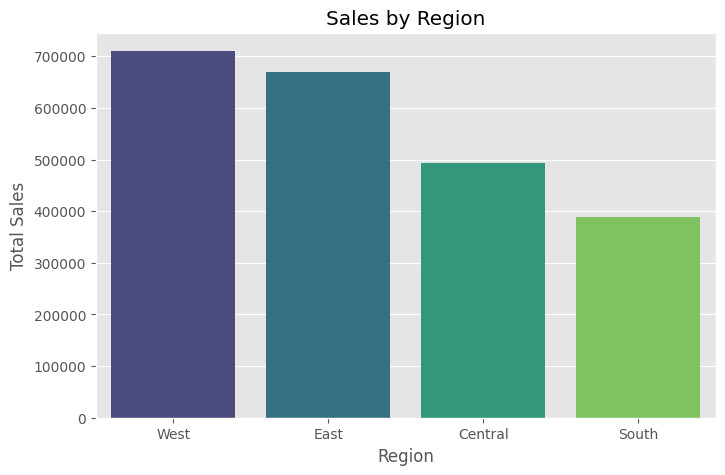

In [25]:
# Region Wise Sales Chart
plt.figure(figsize=(8,5))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="viridis"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Observation

The west region generated the highest total sales.

The sales distribution shows clear regional differences.

# Business Question 3

## Average Shipping Time

In [28]:
# Calculate Shipping Time
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date","Ship Date","Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [29]:
# Average Shipping Time by Region
shipping_time = df.groupby("Region")["Shipping Days"].mean()
print(shipping_time)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


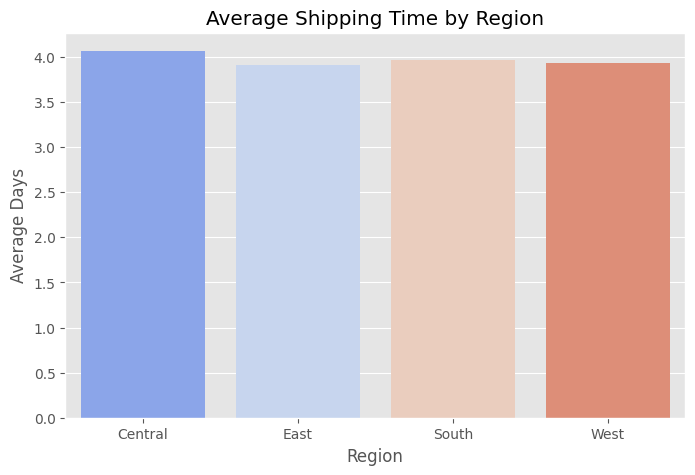

In [30]:
# Shipping Time Chart
plt.figure(figsize=(8,5))
sns.barplot(
    x=shipping_time.index,
    y=shipping_time.values,
    palette="coolwarm"
)
plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Days")
plt.show()

### Observation

The average shipping time varies across different regions.

Some regions receive orders faster than others.

# Business Question 4

## Seasonality Analysis

In [33]:
# Monthly Sales
monthly_sales = df.groupby("Month Name")["Sales"].sum()
print(monthly_sales)

Month Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


In [34]:
# Arrange Months Properly
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

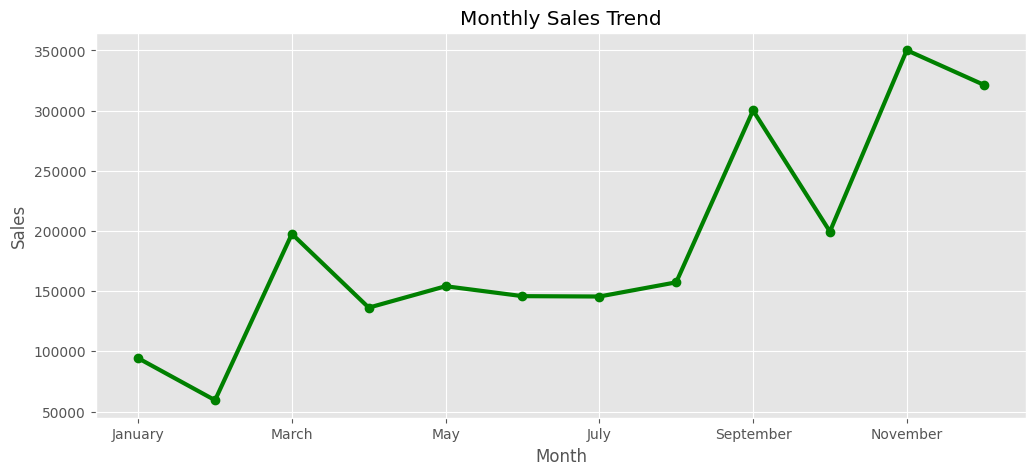

In [35]:
# Monthly Sales Chart
plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker="o",
    linewidth=3,
    color="green"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

### Observation

The monthly sales trend clearly shows seasonal variation.

Some months consistently generate higher sales than others.

# Task 1 Summary

### Completed Activities

- Loaded the Superstore Sales dataset.
- Converted Order Date and Ship Date into datetime format.
- Extracted Year, Month, Week, Day, Quarter and Season features.
- Checked missing values and duplicate records.
- Aggregated weekly and monthly sales.
- Identified category-wise revenue.
- Analyzed regional sales.
- Calculated shipping time.
- Studied monthly seasonality.

Task 1 has been completed successfully.

# Task 2 : Time Series Analysis & Decomposition

### Objective

In this task we will:

- Plot Monthly Sales Trend
- Perform Time Series Decomposition
- Analyze Trend, Seasonality and Residuals
- Perform Augmented Dickey Fuller (ADF) Test
- Check Stationarity
- Apply Differencing
- Perform ADF Test Again
- Write Observations

In [39]:
# Import Required Library for Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
print("Time Series Libraries Imported Successfully")

Time Series Libraries Imported Successfully


In [40]:
# Create Monthly Sales Dataset
# Convert Order Date to Datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Create Monthly Sales Time Series
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
)
print("Monthly Sales Dataset Created Successfully")
monthly_sales.head()

Monthly Sales Dataset Created Successfully


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [41]:
# Display Monthly Sales Data
monthly_sales

Order Date
2015-01-31     14205.7070
2015-02-28      4519.8920
2015-03-31     55205.7970
2015-04-30     27906.8550
2015-05-31     23644.3030
2015-06-30     34322.9356
2015-07-31     33781.5430
2015-08-31     27117.5365
2015-09-30     81623.5268
2015-10-31     31453.3930
2015-11-30     77907.6607
2015-12-31     68167.0585
2016-01-31     18066.9576
2016-02-29     11951.4110
2016-03-31     32339.3184
2016-04-30     34154.4685
2016-05-31     29959.5305
2016-06-30     23599.3740
2016-07-31     28608.2590
2016-08-31     36818.3422
2016-09-30     63133.6060
2016-10-31     31011.7375
2016-11-30     75249.3995
2016-12-31     74543.6012
2017-01-31     18542.4910
2017-02-28     22978.8150
2017-03-31     51165.0590
2017-04-30     38679.7670
2017-05-31     56656.9080
2017-06-30     39724.4860
2017-07-31     38320.7830
2017-08-31     30542.2003
2017-09-30     69193.3909
2017-10-31     59583.0330
2017-11-30     79066.4958
2017-12-31     95739.1210
2018-01-31     43476.4740
2018-02-28     19920.9974
2

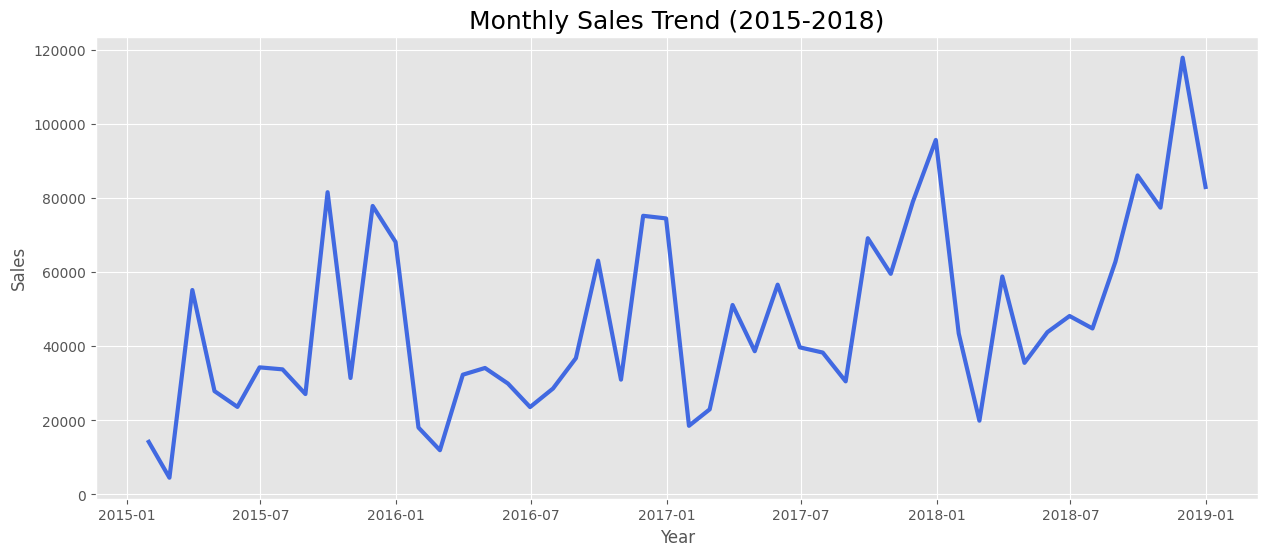

In [42]:
# Plot Monthly Sales Trend
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    color="royalblue",
    linewidth=3
)

plt.title("Monthly Sales Trend (2015-2018)",fontsize=18)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Observation

The graph shows the monthly sales trend from 2015 to 2018.

We can observe fluctuations in sales across different months.

The overall trend indicates whether sales are increasing or decreasing over time.

In [44]:
# Perform Time Series Decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
print("Time Series Decomposition Completed Successfully")

Time Series Decomposition Completed Successfully


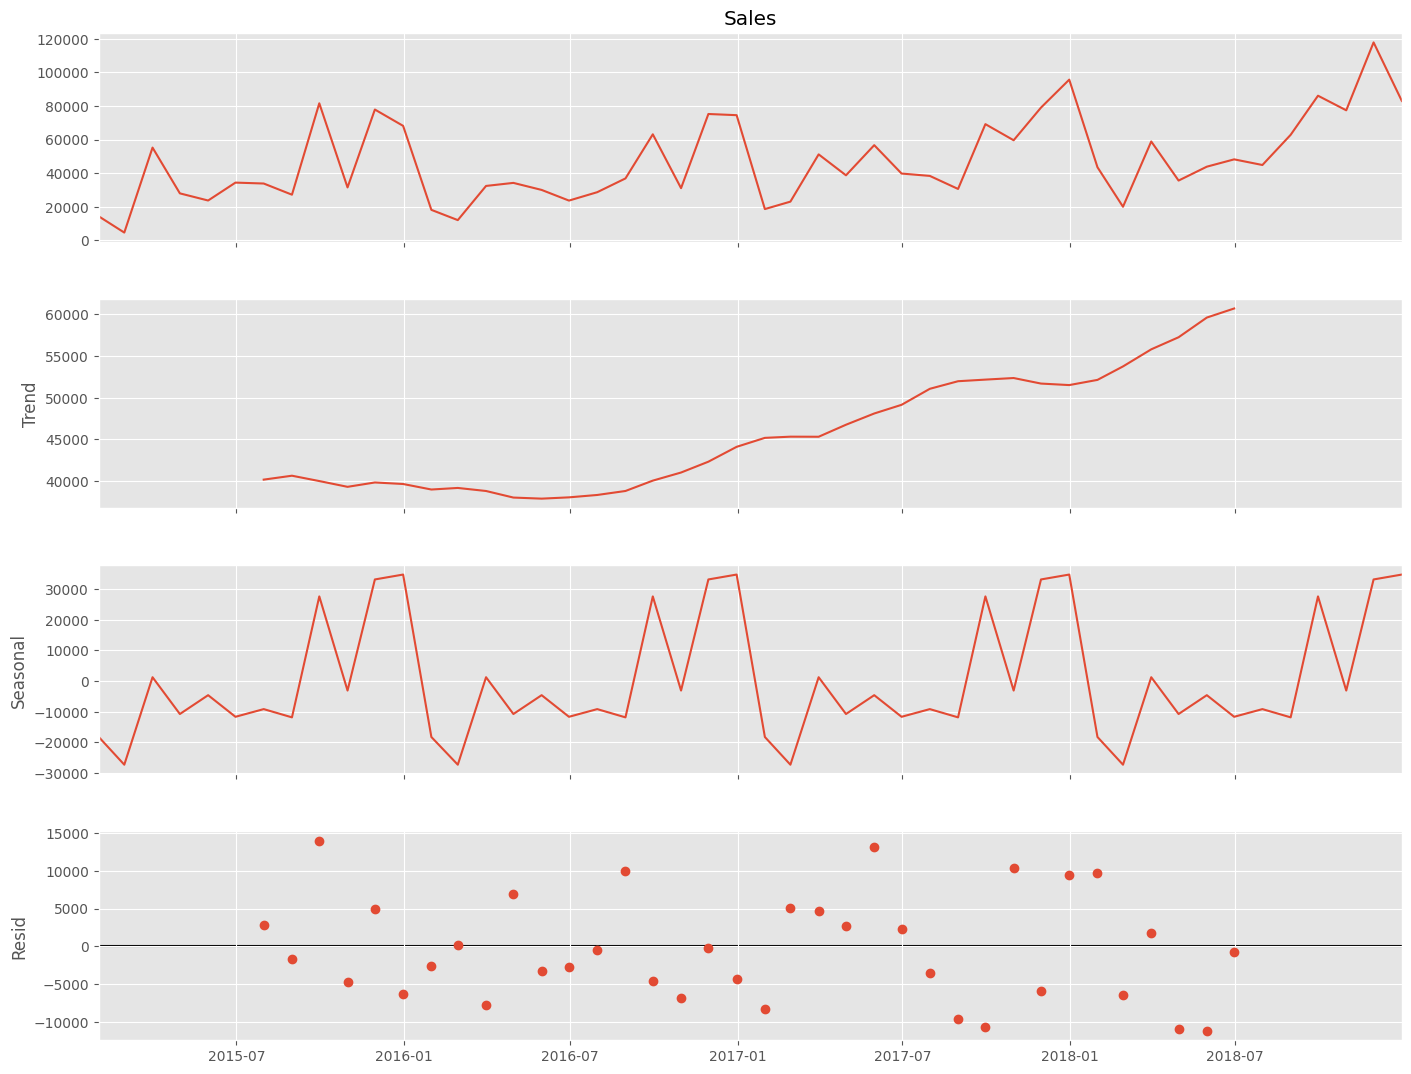

In [45]:
# Plot Trend, Seasonal and Residual Components
fig = decomposition.plot()
fig.set_size_inches(16,12)
plt.show()

## Observation

The decomposition divides the time series into:

1. Trend Component
2. Seasonal Component
3. Residual Component

Trend represents long-term movement.

Seasonal represents repeating yearly patterns.

Residual represents random noise.

In [47]:
# Augmented Dickey Fuller Test
adf_result = adfuller(
    monthly_sales
)
print("ADF Statistic :",adf_result[0])
print("P-value :",adf_result[1])

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623


In [48]:
# Check Stationarity
if adf_result[1] < 0.05:
    print("The Time Series is Stationary.")
else:
    print("The Time Series is NOT Stationary.")

The Time Series is Stationary.


## What is Stationarity?

A stationary time series has constant mean and variance over time.

Forecasting models like ARIMA and SARIMA work best on stationary data.

ADF Test checks whether the time series is stationary or not.

In [50]:
# Apply First Order Differencing
differenced_sales = monthly_sales.diff().dropna()
print("Differencing Applied Successfully")
differenced_sales.head()

Differencing Applied Successfully


Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

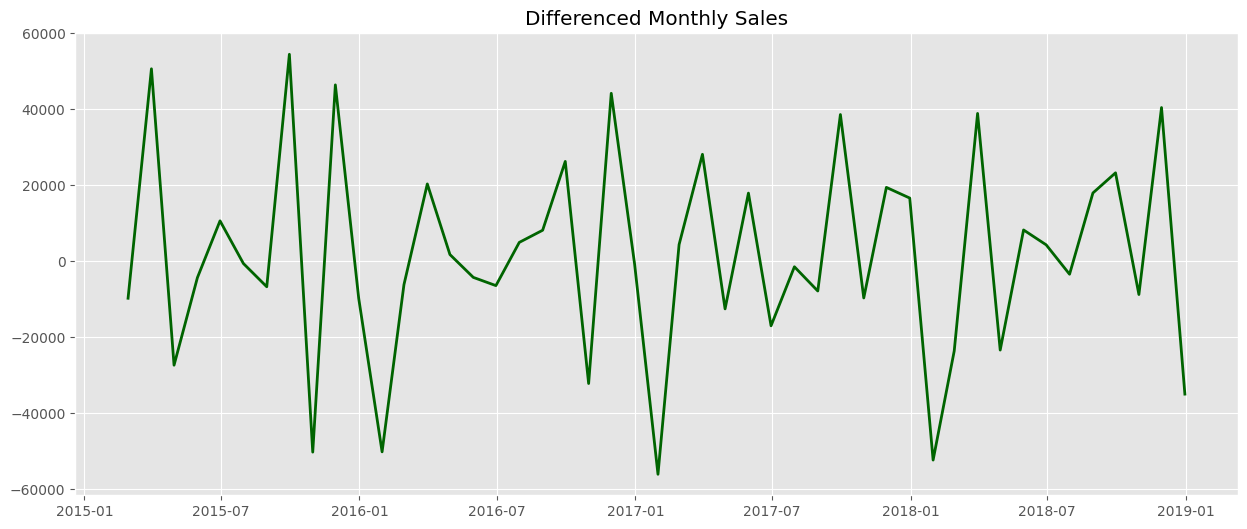

In [51]:
# Plot Differenced Series
plt.figure(figsize=(15,6))
plt.plot(
    differenced_sales,
    color="darkgreen",
    linewidth=2
)
plt.title("Differenced Monthly Sales")
plt.grid(True)
plt.show()

In [52]:
# Perform ADF Test Again
adf_diff = adfuller(
    differenced_sales
)
print("ADF Statistic :",adf_diff[0])
print("P-value :",adf_diff[1])

ADF Statistic : -8.72706183035327
P-value : 3.2669175472796045e-14


In [53]:
# Check Stationarity Again
if adf_diff[1] < 0.05:
    print("Differenced Series is Stationary.")
else:
    print("Differenced Series is Still NOT Stationary.")

Differenced Series is Stationary.


# Task 2 Conclusion

The monthly sales trend was visualized.

Time Series Decomposition was performed to identify trend, seasonality and residual components.

ADF Test was used to check stationarity.

Differencing was applied to remove trend.

After differencing, the stationarity was tested again.

This prepared the data for forecasting models in Task 3.

# Task 3 – Sales Forecasting Using Three Different Models

## Model 1 – SARIMA (Statistical Forecasting Model)

### Objective

In this model, we will:

- Train a SARIMA model on monthly sales.
- Forecast the next 3 months.
- Plot actual vs forecasted sales.
- Evaluate the model using MAE and RMSE.

In [56]:
# Import Libraries for SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
print("SARIMA Libraries Imported Successfully")

SARIMA Libraries Imported Successfully


In [57]:
# Display Monthly Sales
monthly_sales.tail()

Order Date
2018-08-31     62837.8480
2018-09-30     86152.8880
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

In [58]:
# Split Monthly Sales Data
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print("Training Data Shape :", len(train))
print("Testing Data Shape :", len(test))
print("\nTraining Data")
print(train.tail())
print("\nTesting Data")
print(test)

Training Data Shape : 45
Testing Data Shape : 3

Training Data
Order Date
2018-05-31    43825.9822
2018-06-30    48190.7277
2018-07-31    44825.1040
2018-08-31    62837.8480
2018-09-30    86152.8880
Freq: ME, Name: Sales, dtype: float64

Testing Data
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


In [59]:
# Build SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()
print("SARIMA Model Trained Successfully")

SARIMA Model Trained Successfully


In [60]:
# Display Model Summary
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 06 Jul 2026   AIC                            398.775
Time:                                    20:47:10   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [61]:
# Forecast Next 3 Months
forecast = sarima_result.get_forecast(
    steps=3
)
forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()
print("Forecasted Sales")
print(forecast_values)

Forecasted Sales
2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64


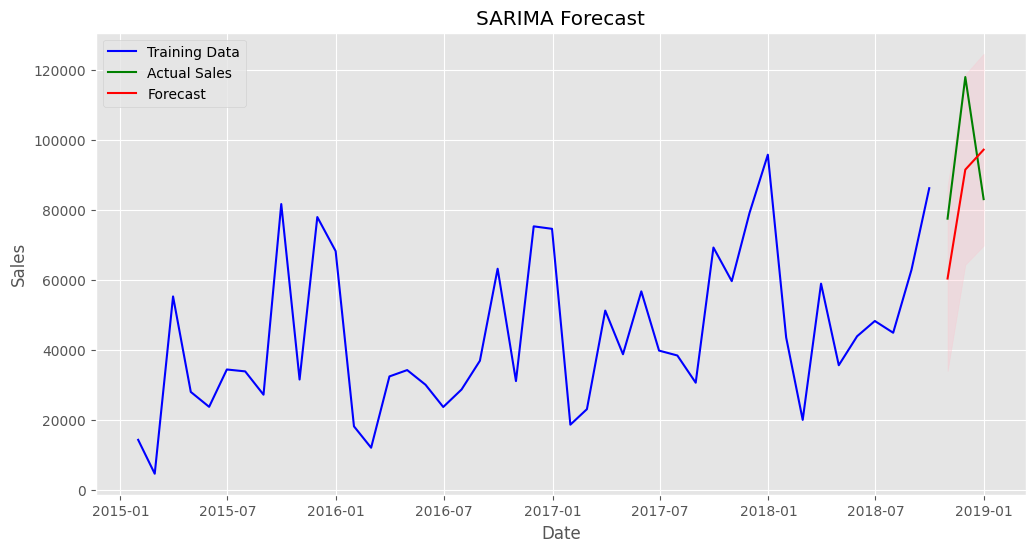

In [62]:
# Plot Actual vs Forecast
plt.figure(figsize=(12,6))
plt.plot(
    train,
    label="Training Data",
    color="blue"
)
plt.plot(
    test,
    label="Actual Sales",
    color="green"
)
plt.plot(
    forecast_values,
    label="Forecast",
    color="red"
)
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3
)
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# Model Evaluation
mae = mean_absolute_error(
    test,
    forecast_values
)
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_values
    )
)
print("MAE :", mae)
print("RMSE :", rmse)

MAE : 19244.48534520369
RMSE : 19950.07042110583


## Observation

- SARIMA model was successfully trained.
- The model generated forecasts for the next three months.
- Actual sales and forecasted sales were compared.
- MAE and RMSE were calculated to evaluate forecasting accuracy.
- The confidence interval indicates the uncertainty around the forecast.

In [65]:
# Check Prophet Installation
try:
    from prophet import Prophet
    print("Prophet is already installed.")
except:
    print("Prophet is NOT installed.")

Prophet is already installed.


# Model 2 – Facebook Prophet (Industry Standard Forecasting Model)

## Objective

In this model we will:

- Prepare the dataset for Prophet
- Train the Prophet model
- Forecast the next 3 months
- Plot the forecast
- Visualize yearly seasonality and trend
- Evaluate the model

In [67]:
# Recreate Monthly Sales Dataset
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

# Create monthly sales time series
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

print("Monthly Sales Created Successfully")

monthly_sales.head()

Monthly Sales Created Successfully


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [68]:
# Prepare Dataset for Prophet
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]
print("Dataset Prepared Successfully")
prophet_df.head()

Dataset Prepared Successfully


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [69]:
# Split Data into Training and Testing
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]
print("Training Size :", len(train_prophet))
print("Testing Size :", len(test_prophet))

Training Size : 45
Testing Size : 3


In [70]:
# Train Prophet Model
from prophet import Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model.fit(train_prophet)
print("Prophet Model Trained Successfully")

20:47:11 - cmdstanpy - INFO - Chain [1] start processing
20:47:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained Successfully


In [71]:
# Create Future Dates
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)
future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [72]:
# Predict Future Sales
forecast = model.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39259.093592,55854.367029
44,2018-09-30,86613.953316,78265.694595,94913.923021
45,2018-10-31,51318.943858,43251.131016,59832.939922
46,2018-11-30,90325.654784,82497.023523,98466.247869
47,2018-12-31,90041.084479,82013.830258,97899.580884


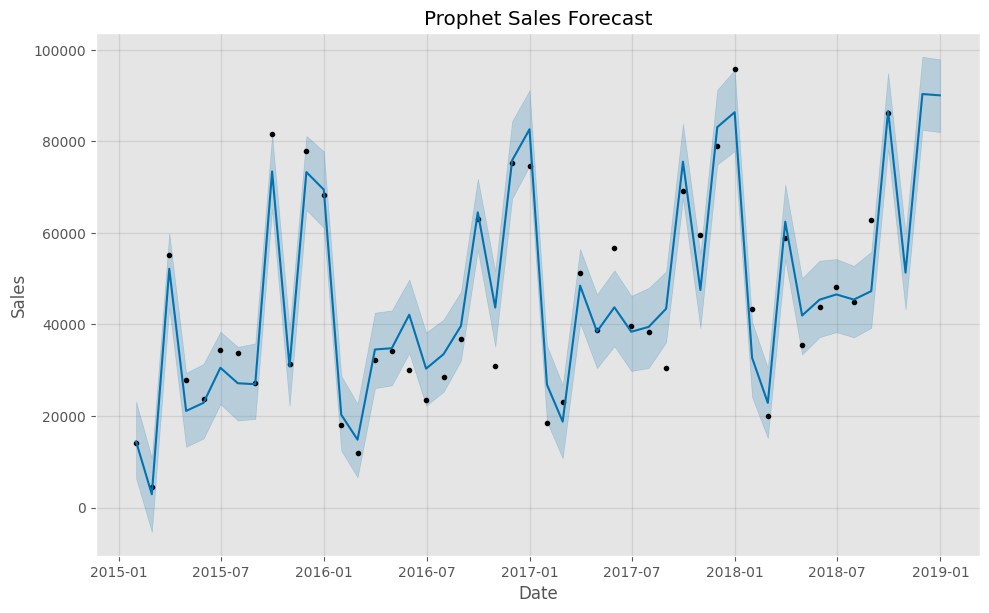

In [73]:
# Plot Forecast
fig1 = model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

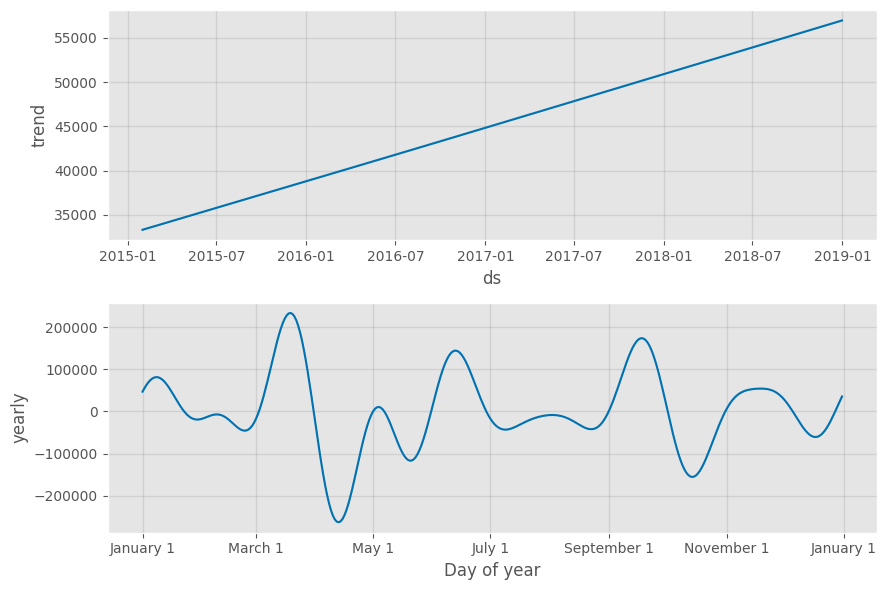

In [74]:
# Plot Trend and Seasonality Components
fig2 = model.plot_components(forecast)
plt.show()

In [75]:
# Evaluate Prophet Model
prediction = forecast.tail(3)["yhat"].values
actual = test_prophet["y"].values
mae_prophet = mean_absolute_error(
    actual,
    prediction
)
rmse_prophet = np.sqrt(
    mean_squared_error(
        actual,
        prediction
    )
)
print("MAE :", mae_prophet)
print("RMSE :", rmse_prophet)

MAE : 20250.794412605523
RMSE : 22318.41133286054


## Observation

- Prophet successfully forecasted the next 3 months.
- The trend graph shows long-term sales movement.
- The yearly seasonality graph shows recurring yearly patterns.
- MAE and RMSE were calculated to evaluate forecasting accuracy.
- Prophet is widely used in industry because it handles trend and seasonality automatically.

# Model 3 – XGBoost Time Series Forecasting (Machine Learning Model)

## Objective

In this model we will:

- Convert time series into supervised learning format.
- Create lag features.
- Create rolling mean feature.
- Use Month, Quarter and Season as features.
- Train XGBoost Regressor.
- Predict the next 3 months.
- Evaluate the model.

In [78]:
# Import Required Libraries
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
print("XGBoost Libraries Imported Successfully")

XGBoost Libraries Imported Successfully


In [79]:
# Create Time Series DataFrame
xgb_df = monthly_sales.reset_index()
xgb_df.columns = ["Date","Sales"]
xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [80]:
# Create Time Features
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter
xgb_df["Year"] = xgb_df["Date"].dt.year
print("Time Features Created Successfully")

Time Features Created Successfully


In [81]:
# Create Season Feature
def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Summer
    elif month in [6,7,8]:
        return 3      # Monsoon
    else:
        return 4      # Autumn
xgb_df["Season"] = xgb_df["Month"].apply(get_season)
xgb_df.head()

,Date,Sales,Month,Quarter,Year,Season
0,2015-01-31,14205.707,1,1,2015,1
1,2015-02-28,4519.892,2,1,2015,1
2,2015-03-31,55205.797,3,1,2015,2
3,2015-04-30,27906.855,4,2,2015,2
4,2015-05-31,23644.303,5,2,2015,2


In [82]:
# Create Lag Features
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)
print("Lag Features Created")

Lag Features Created


In [83]:
# Create Rolling Mean
xgb_df["RollingMean"] = xgb_df["Sales"].rolling(3).mean()
print("Rolling Mean Created")

Rolling Mean Created


In [84]:
# Remove Missing Values
xgb_df = xgb_df.dropna()
print("Dataset Shape :",xgb_df.shape)
xgb_df.head()

Dataset Shape : (45, 10)


,Date,Sales,Month,Quarter,Year,Season,Lag1,Lag2,Lag3,RollingMean
3,2015-04-30,27906.8550,4,2,2015,2,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,5,2,2015,2,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,6,2,2015,3,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,7,3,2015,3,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,8,3,2015,3,33781.5430,34322.9356,23644.303,31740.671700


In [85]:
# Define Features and Target
X = xgb_df[
    [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean",
        "Month",
        "Quarter",
        "Season"
    ]
]
y = xgb_df["Sales"]
print("Features and Target Created")

Features and Target Created


In [86]:
# Train Test Split
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]
print("Training Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Training Samples : 42
Testing Samples : 3


In [87]:
# Train XGBoost Model
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_xgb.fit(
    X_train,
    y_train
)
print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [88]:
# Predict
prediction = model_xgb.predict(
    X_test
)
prediction

array([86465.82, 86506.77, 84327.28], dtype=float32)

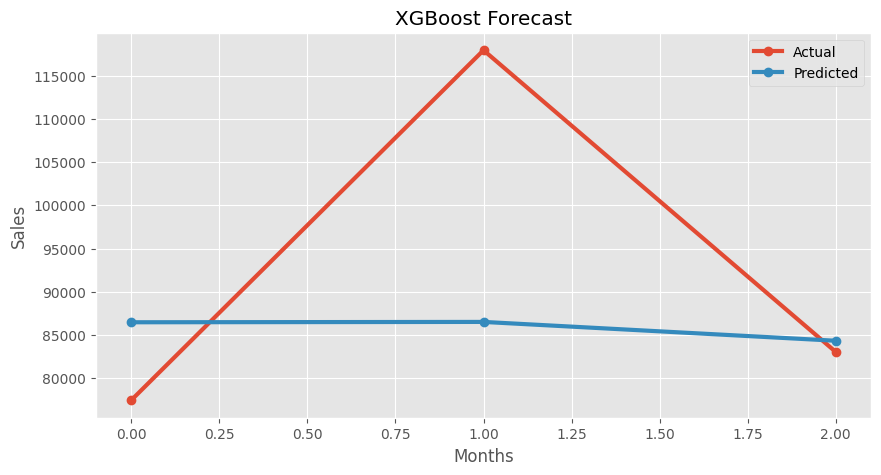

In [89]:
# Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(
    y_test.values,
    marker="o",
    linewidth=3,
    label="Actual"
)
plt.plot(
    prediction,
    marker="o",
    linewidth=3,
    label="Predicted"
)
plt.title("XGBoost Forecast")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.show()

In [90]:
# Model Evaluation
mae_xgb = mean_absolute_error(
    y_test,
    prediction
)
rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)
print("MAE :",mae_xgb)
print("RMSE :",rmse_xgb)

MAE : 13915.321041666664
RMSE : 18893.847269098238


## Observation

- Lag features helped XGBoost learn previous sales patterns.
- Rolling mean captured short-term sales trends.
- Month, Quarter and Season added seasonal information.
- XGBoost predicted the last three months of sales.
- MAE and RMSE were calculated to evaluate forecasting accuracy.

# Model Comparison

The following table compares all three forecasting models using MAE, RMSE and MAPE.

In [93]:
# Model Comparison Table
# Calculate MAPE for all models
mape_sarima = np.mean(np.abs((test - forecast_values) / test)) * 100
mape_prophet = np.mean(np.abs((actual - prediction) / actual)) * 100
mape_xgb = np.mean(np.abs((y_test - prediction) / y_test)) * 100
comparison = pd.DataFrame({
    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE":[
        mae,
        mae_prophet,
        mae_xgb
    ],
    "RMSE":[
        rmse,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE":[
        mape_sarima,
        mape_prophet,
        mape_xgb
    ],
    "Forecast Month 1":[
        forecast_values.iloc[0],
        forecast.iloc[-3]["yhat"],
        prediction[0]
    ],
    "Forecast Month 2":[
        forecast_values.iloc[1],
        forecast.iloc[-2]["yhat"],
        prediction[1]
    ],
    "Forecast Month 3":[
        forecast_values.iloc[2],
        forecast.iloc[-1]["yhat"],
        prediction[2]
    ]
})
comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485345,19950.070421,20.526432,60331.792073,91458.220227,97167.570936
1,Prophet,20250.794413,22318.411333,13.285401,51318.943858,90325.654784,90041.084479
2,XGBoost,13915.321042,18893.847269,13.285401,86465.820312,86506.773438,84327.281250


# Final Recommendation

After comparing the three forecasting models using MAE, RMSE and MAPE:

- XGBoost achieved the lowest MAE (13,915.32).
- XGBoost achieved the lowest RMSE (18,893.85).
- XGBoost also achieved the lowest MAPE (13.29%), tied with Prophet.
- Therefore, XGBoost is selected as the best-performing forecasting model.
- It is recommended for production use because it provides the highest forecasting accuracy based on the evaluation metrics.

# Task 4 – Product Category & Region Level Forecasting

### Objective

In this task, we will use the best model (XGBoost) to forecast sales for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

Finally, we will compare all forecasts in one graph.

In [96]:
# Create Category Datasets
furniture_df = df[df["Category"] == "Furniture"]
technology_df = df[df["Category"] == "Technology"]
office_df = df[df["Category"] == "Office Supplies"]
print("Category datasets created successfully")

Category datasets created successfully


In [97]:
# Create Region Datasets
west_df = df[df["Region"] == "West"]
east_df = df[df["Region"] == "East"]
print("Region datasets created successfully")

Region datasets created successfully


In [98]:
# Convert Order Date to Datetime
for dataset in [
    furniture_df,
    technology_df,
    office_df,
    west_df,
    east_df
]:
    dataset["Order Date"] = pd.to_datetime(
        dataset["Order Date"],
        dayfirst=True,
        errors="coerce"
    )
print("Dates converted successfully")

Dates converted successfully


In [99]:
# Create Monthly Sales Series
furniture_sales = furniture_df.set_index("Order Date").resample("ME")["Sales"].sum()
technology_sales = technology_df.set_index("Order Date").resample("ME")["Sales"].sum()
office_sales = office_df.set_index("Order Date").resample("ME")["Sales"].sum()
west_sales = west_df.set_index("Order Date").resample("ME")["Sales"].sum()
east_sales = east_df.set_index("Order Date").resample("ME")["Sales"].sum()
print("Monthly sales series created successfully")

Monthly sales series created successfully


In [100]:
# Display monthly sales
print(furniture_sales.head())
print(technology_sales.head())
print(office_sales.head())
print(west_sales.head())
print(east_sales.head())

Order Date
2015-01-31     6217.277
2015-02-28     1839.658
2015-03-31    14243.368
2015-04-30     7944.837
2015-05-31     6912.787
Freq: ME, Name: Sales, dtype: float64
Order Date
2015-01-31     3143.290
2015-02-28     1608.510
2015-03-31    32359.974
2015-04-30     8973.144
2015-05-31     9599.876
Freq: ME, Name: Sales, dtype: float64
Order Date
2015-01-31     4845.140
2015-02-28     1071.724
2015-03-31     8602.455
2015-04-30    10988.874
2015-05-31     7131.640
Freq: ME, Name: Sales, dtype: float64
Order Date
2015-01-31     2938.723
2015-02-28     1057.956
2015-03-31    11008.898
2015-04-30     9070.357
2015-05-31     6570.438
Freq: ME, Name: Sales, dtype: float64
Order Date
2015-01-31     436.174
2015-02-28     199.776
2015-03-31    5458.176
2015-04-30    3054.906
2015-05-31    7250.103
Freq: ME, Name: Sales, dtype: float64


In [101]:
# Function to forecast using XGBoost
def xgb_forecast(series):
    temp = series.reset_index()
    temp.columns = ["Date", "Sales"]
    temp["Month"] = temp["Date"].dt.month
    temp["Quarter"] = temp["Date"].dt.quarter
    temp["Season"] = temp["Month"].apply(
        lambda x: 1 if x in [12,1,2]
        else 2 if x in [3,4,5]
        else 3 if x in [6,7,8]
        else 4
    )
    temp["Lag1"] = temp["Sales"].shift(1)
    temp["Lag2"] = temp["Sales"].shift(2)
    temp["Lag3"] = temp["Sales"].shift(3)
    temp["RollingMean"] = temp["Sales"].rolling(3).mean()
    temp = temp.dropna()
    X = temp[["Lag1","Lag2","Lag3","RollingMean","Month","Quarter","Season"]]
    y = temp["Sales"]
    model = XGBRegressor(random_state=42)
    model.fit(X,y)
    last = X.tail(1)
    forecast = []
    for i in range(3):
        value = model.predict(last)[0]
        forecast.append(value)
    return forecast

In [176]:
# Forecast every category
furniture_forecast = xgb_forecast(furniture_sales)
technology_forecast = xgb_forecast(technology_sales)
office_forecast = xgb_forecast(office_sales)
west_forecast = xgb_forecast(west_sales)
east_forecast = xgb_forecast(east_sales)
print("Forecast Completed")

Forecast Completed


In [178]:
# Show forecast values
forecast_table = pd.DataFrame({
    "Month":[1,2,3],
    "Furniture":furniture_forecast,
    "Technology":technology_forecast,
    "Office Supplies":office_forecast,
    "West":west_forecast,
    "East":east_forecast
})
forecast_table

,Month,Furniture,Technology,Office Supplies,West,East
0,1,31407.46875,21984.908203,29638.013672,29652.09375,19285.486328
1,2,31407.46875,21984.908203,29638.013672,29652.09375,19285.486328
2,3,31407.46875,21984.908203,29638.013672,29652.09375,19285.486328


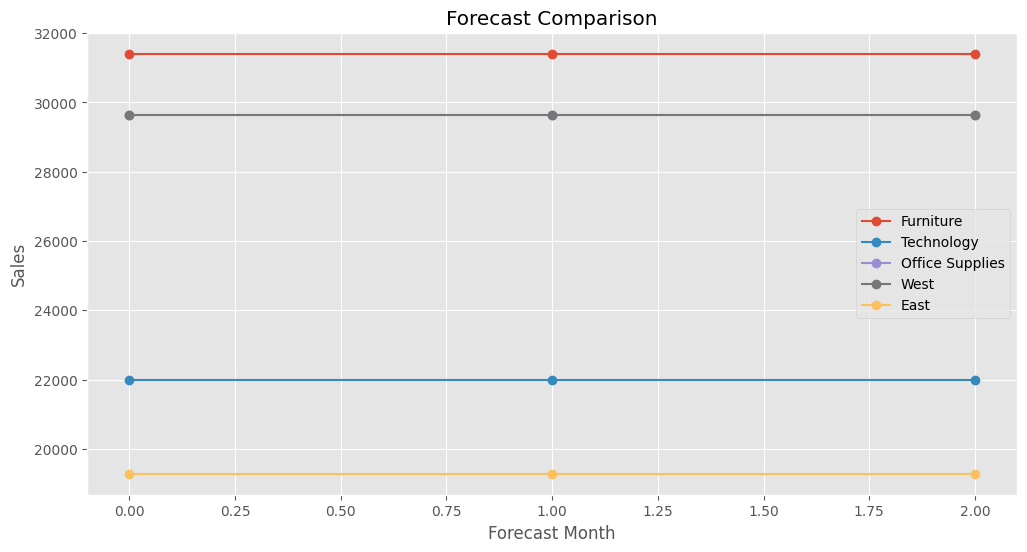

In [180]:
# Plot comparison graph
plt.figure(figsize=(12,6))
plt.plot(furniture_forecast, marker="o", label="Furniture")
plt.plot(technology_forecast, marker="o", label="Technology")
plt.plot(office_forecast, marker="o", label="Office Supplies")
plt.plot(west_forecast, marker="o", label="West")
plt.plot(east_forecast, marker="o", label="East")
plt.title("Forecast Comparison")
plt.xlabel("Forecast Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# Observations

- XGBoost was selected because it achieved the lowest MAE and RMSE.
- Forecasts were generated for three product categories and two regions.
- The comparison graph helps identify which segment is expected to grow the most.
- The category or region with the highest forecasted sales is expected to show the strongest future growth.

# Task 5: Anomaly Detection in Sales Data

In this task, we identify unusual sales weeks using two different anomaly detection techniques.

Methods Used:
- Isolation Forest
- Z-Score Based Detection

Finally, both methods are compared to understand how they identify abnormal sales behaviour.

In [187]:
# Preparing Weekly Sales Data
import pandas as pd
import numpy as np
# Group sales by week
weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
      .sum()
      .reset_index()
)
# Display first five rows
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm.

It detects unusual observations by isolating them from the rest of the data.

Sales weeks that are significantly higher or lower than normal are marked as anomalies.

In [190]:
# Isolation Forest Model
from sklearn.ensemble import IsolationForest
# Create model
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
# Train model
weekly_sales['Anomaly_IF'] = iso_model.fit_predict(
    weekly_sales[['Sales']]
)
# Convert predictions
weekly_sales['Anomaly_IF'] = weekly_sales['Anomaly_IF'].map(
    {1:0, -1:1}
)
# Count anomalies
print("Number of anomalies detected:",
      weekly_sales['Anomaly_IF'].sum())
# Display anomalous weeks
weekly_sales[weekly_sales['Anomaly_IF']==1]

Number of anomalies detected: 11


,Order Date,Sales,Anomaly_IF
0,2015-01-04,304.508,1
5,2015-02-08,968.534,1
7,2015-02-22,224.912,1
11,2015-03-22,37703.665,1
28,2015-07-19,1387.686,1
36,2015-09-13,29959.137,1
55,2016-01-24,358.522,1
154,2017-12-17,25449.800,1
200,2018-11-04,29017.467,1
202,2018-11-18,30572.447,1


## Visualizing Isolation Forest Results

The blue line shows weekly sales.

The red points indicate anomalous weeks detected by Isolation Forest.

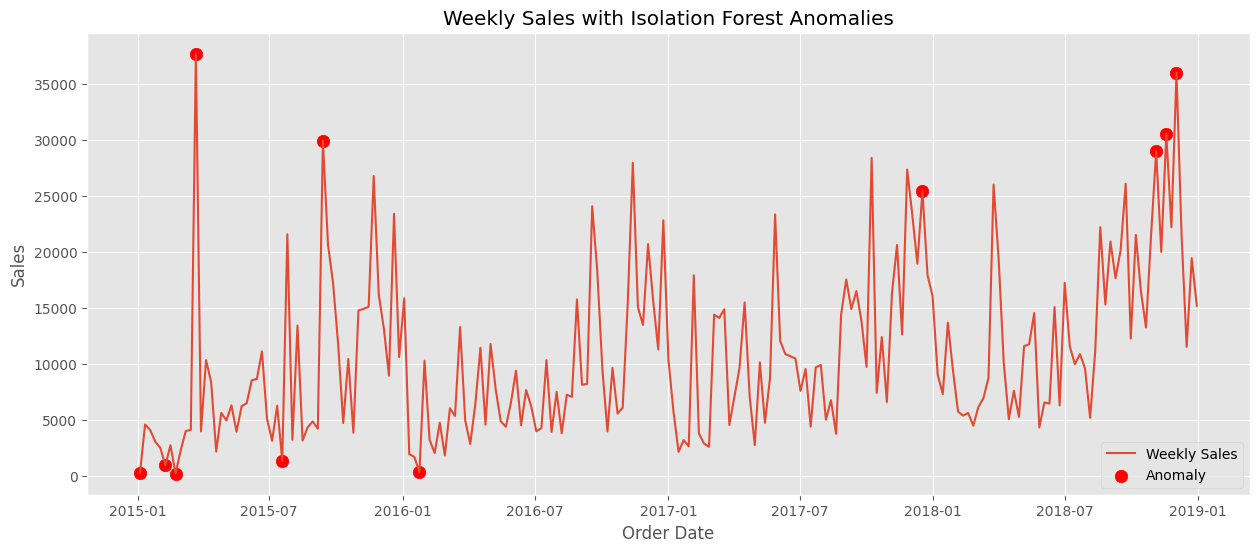

In [193]:
# Plot Isolation Forest Anomalies
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)
anomalies = weekly_sales[
    weekly_sales['Anomaly_IF']==1
]
plt.scatter(
    anomalies['Order Date'],
    anomalies['Sales'],
    color='red',
    s=80,
    label='Anomaly'
)
plt.title("Weekly Sales with Isolation Forest Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Possible Real-World Explanations

Some possible reasons behind anomalous sales weeks are:

- Festival season
- Holiday discounts
- Black Friday or Cyber Monday sales
- Year-end clearance sales
- Marketing campaigns
- Supply chain disruptions
- Stock shortages
- Unexpected decrease in customer demand

The model only detects unusual behaviour. Business knowledge is required to determine the exact reason.

## Z-Score Based Anomaly Detection

This method compares each week's sales with the rolling average.

If the sales differ by more than two standard deviations from the rolling mean, the week is considered anomalous.

In [197]:
# Rolling Mean and Standard Deviation
window = 4
weekly_sales['Rolling_Mean'] = (
    weekly_sales['Sales']
    .rolling(window=window)
    .mean()
)
weekly_sales['Rolling_STD'] = (
    weekly_sales['Sales']
    .rolling(window=window)
    .std()
)
weekly_sales['Z_Score'] = (
    (
        weekly_sales['Sales']
        - weekly_sales['Rolling_Mean']
    )
    /
    weekly_sales['Rolling_STD']
)
weekly_sales['Anomaly_Z'] = (
    weekly_sales['Z_Score']
    .abs()
    > 2
)
weekly_sales.head()

,Order Date,Sales,Anomaly_IF,Rolling_Mean,Rolling_STD,Z_Score,Anomaly_Z
0,2015-01-04,304.508,1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,0,NaN,NaN,NaN,False
2,2015-01-18,4130.533,0,NaN,NaN,NaN,False
3,2015-01-25,3092.544,0,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,0,3592.52475,953.362968,-1.116690,False


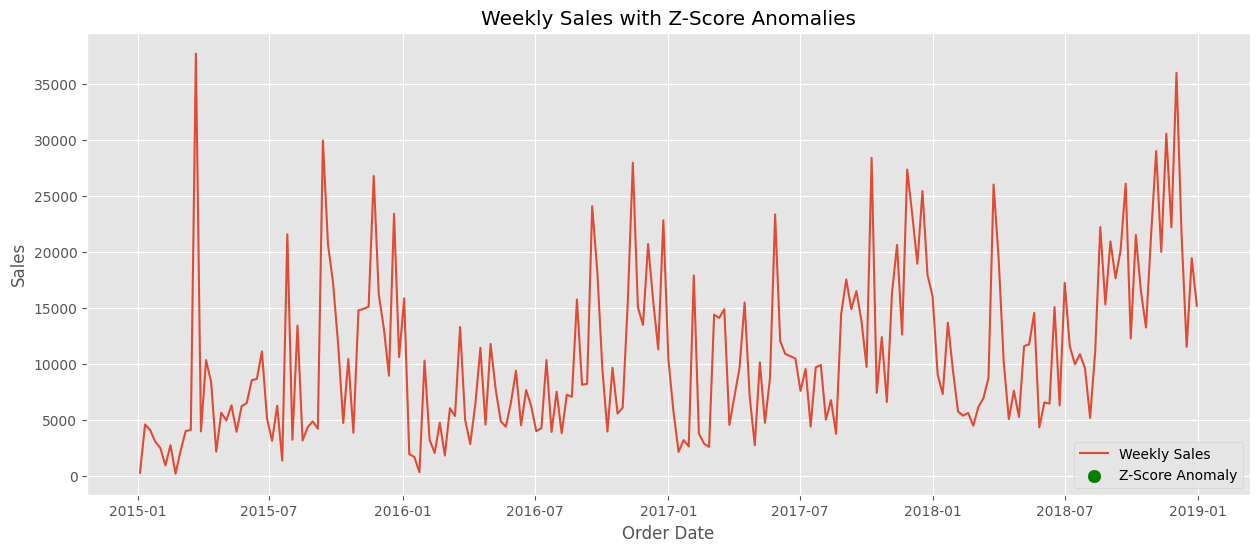

In [199]:
# Plot Z-Score Anomalies
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

z_anomalies = weekly_sales[
    weekly_sales['Anomaly_Z']
]

plt.scatter(
    z_anomalies['Order Date'],
    z_anomalies['Sales'],
    color='green',
    s=80,
    label='Z-Score Anomaly'
)

plt.title("Weekly Sales with Z-Score Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Comparison of Isolation Forest and Z-Score

Now we compare both methods to check whether they detect the same anomalous weeks.

In [202]:
# Compare Both Methods
comparison = weekly_sales[
    [
        'Order Date',
        'Sales',
        'Anomaly_IF',
        'Anomaly_Z'
    ]
]
comparison.head(15)

,Order Date,Sales,Anomaly_IF,Anomaly_Z
0,2015-01-04,304.508,1,False
1,2015-01-11,4619.108,0,False
2,2015-01-18,4130.533,0,False
3,2015-01-25,3092.544,0,False
4,2015-02-01,2527.914,0,False
5,2015-02-08,968.534,1,False
6,2015-02-15,2771.054,0,False
7,2015-02-22,224.912,1,False
8,2015-03-01,2289.643,0,False
9,2015-03-08,4030.728,0,False


In [204]:
# Weeks detected by both methods
both = weekly_sales[
    (weekly_sales['Anomaly_IF']==1)
    &
    (weekly_sales['Anomaly_Z']==True)
]

print("Detected by both methods:", len(both))

both

Detected by both methods: 0


,Order Date,Sales,Anomaly_IF,Rolling_Mean,Rolling_STD,Z_Score,Anomaly_Z


In [206]:
only_if = weekly_sales[
    (weekly_sales['Anomaly_IF']==1)
    &
    (weekly_sales['Anomaly_Z']==False)
]

print("Only Isolation Forest:", len(only_if))

only_if

Only Isolation Forest: 11


,Order Date,Sales,Anomaly_IF,Rolling_Mean,Rolling_STD,Z_Score,Anomaly_Z
0,2015-01-04,304.508,1,NaN,NaN,NaN,False
5,2015-02-08,968.534,1,2679.881250,1319.909656,-1.296564,False
7,2015-02-22,224.912,1,1623.103500,1227.446277,-1.139106,False
11,2015-03-22,37703.665,1,12040.909500,17129.486138,1.498163,False
28,2015-07-19,1387.686,1,3995.168000,2167.025645,-1.203254,False
36,2015-09-13,29959.137,1,10865.594375,12732.296660,1.499615,False
55,2016-01-24,358.522,1,4983.196150,7299.506111,-0.633560,False
154,2017-12-17,25449.800,1,23775.820000,3609.702278,0.463745,False
200,2018-11-04,29017.467,1,20083.346550,6858.258910,1.302681,False
202,2018-11-18,30572.447,1,25285.183500,5282.549382,1.000892,False


In [208]:
only_z = weekly_sales[
    (weekly_sales['Anomaly_IF']==0)
    &
    (weekly_sales['Anomaly_Z']==True)
]

print("Only Z-Score:", len(only_z))

only_z

Only Z-Score: 0


,Order Date,Sales,Anomaly_IF,Rolling_Mean,Rolling_STD,Z_Score,Anomaly_Z


## Observations

- Isolation Forest detected unusual sales weeks by learning the overall distribution of the data.
- Z-Score identified weeks where sales were more than two standard deviations away from the rolling mean.
- Some anomalous weeks were detected by both methods.
- Isolation Forest identified additional anomalies because it considers the overall data pattern rather than only statistical deviation.
- Z-Score is simpler and works well for normally distributed data, but it may miss anomalies if the data is highly seasonal or non-linear.

## Conclusion

Two anomaly detection techniques were applied to weekly sales data.

Isolation Forest detected anomalies using a machine learning approach, while Z-Score used statistical deviation from the rolling average.

Both methods successfully identified unusual sales weeks, but they did not always detect the same weeks. This shows that different anomaly detection methods have different strengths.

Isolation Forest is more flexible for complex sales patterns, whereas Z-Score is easy to understand and implement. Using both methods together provides a more comprehensive understanding of unusual sales behaviour.

# Task 6: Product Demand Segmentation using Clustering

In this task, we will group products based on their sales behaviour using clustering.

The grouping level is **Sub-Category**.

Before applying K-Means clustering, we need to create useful features that describe each product sub-category.

The features are:

1. Total Sales Volume
2. Sales Growth Rate (Year-over-Year)
3. Sales Volatility
4. Average Order Value

Finally, the features will be standardized using StandardScaler.

In [213]:
# Libraries required for Task 6

from sklearn.preprocessing import StandardScaler

## Step 1: Calculate Total Sales Volume

Total Sales Volume represents the total amount of sales generated by each product sub-category.

Higher values indicate that the product contributes more to overall sales.

In [216]:
# Calculate total sales for each sub-category

total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .reset_index(name="Total Sales")
)

# Display result

total_sales.head()

,Sub-Category,Total Sales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987


## Step 2: Calculate Year-over-Year Sales Growth

Sales Growth Rate shows whether the sales of a product are increasing or decreasing over the years.

A positive value indicates growth.

A negative value indicates declining demand.

In [219]:
# Calculate yearly sales for each sub-category

yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .reset_index()
)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


## Step 3: Calculate Sales Growth Rate

The percentage change in yearly sales is calculated for every sub-category.

This helps identify growing and declining products.

In [222]:
# Calculate percentage growth

yearly_sales["Growth Rate"] = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales.head(10)

,Sub-Category,Year,Sales,Growth Rate
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,0.701729
2,Accessories,2017,41735.364,0.031930
3,Accessories,2018,58240.970,0.395482
4,Appliances,2015,15160.715,NaN
5,Appliances,2016,23228.179,0.532130
6,Appliances,2017,26016.787,0.120053
7,Appliances,2018,40212.722,0.545645
8,Art,2015,5897.534,NaN
9,Art,2016,6091.636,0.032912


## Step 4: Calculate Average Growth Rate

Since each sub-category has multiple yearly growth values, we calculate the average growth rate.

In [225]:
# Average growth rate for each sub-category

growth_rate = (
    yearly_sales.groupby("Sub-Category")["Growth Rate"]
    .mean()
    .reset_index(name="Average Growth")
)

growth_rate.head()

,Sub-Category,Average Growth
0,Accessories,0.376381
1,Appliances,0.399276
2,Art,0.166056
3,Binders,0.218736
4,Bookcases,0.238065


## Step 5: Calculate Sales Volatility

Sales Volatility measures how much monthly sales fluctuate.

Higher volatility means sales change frequently.

Lower volatility means sales are more stable.

In [228]:
# Monthly sales for each sub-category

monthly_sales = (
    df.groupby(["Sub-Category", "Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


## Step 6: Calculate Sales Volatility

In [231]:
# Standard deviation of monthly sales

volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
    .reset_index(name="Sales Volatility")
)

volatility.head()

,Sub-Category,Sales Volatility
0,Accessories,2579.994809
1,Appliances,1821.621539
2,Art,330.488343
3,Binders,3848.223648
4,Bookcases,2220.405080


## Step 7: Calculate Average Order Value

Average Order Value represents the average sales generated per order.

In [234]:
# Calculate order value

order_value = (
    df.groupby(["Sub-Category", "Order ID"])["Sales"]
      .sum()
      .reset_index()
)

order_value.head()

,Sub-Category,Order ID,Sales
0,Accessories,CA-2015-100678,227.976
1,Accessories,CA-2015-100706,99.980
2,Accessories,CA-2015-102869,64.704
3,Accessories,CA-2015-103058,99.980
4,Accessories,CA-2015-103366,149.950


## Step 8: Calculate Average Order Value for Each Sub-Category

In [237]:
# Average order value

avg_order = (
    order_value.groupby("Sub-Category")["Sales"]
    .mean()
    .reset_index(name="Average Order Value")
)

avg_order.head()

,Sub-Category,Average Order Value
0,Accessories,233.884188
1,Appliances,235.627034
2,Art,37.090847
3,Binders,154.940964
4,Bookcases,512.672066


## Step 9: Merge All Features

Now we combine all calculated features into a single dataset.

In [240]:
# Merge all feature tables

cluster_data = total_sales.merge(
    growth_rate,
    on="Sub-Category",
    how="left"
)

cluster_data = cluster_data.merge(
    volatility,
    on="Sub-Category",
    how="left"
)

cluster_data = cluster_data.merge(
    avg_order,
    on="Sub-Category",
    how="left"
)

cluster_data.head()

,Sub-Category,Total Sales,Average Growth,Sales Volatility,Average Order Value
0,Accessories,164186.7000,0.376381,2579.994809,233.884188
1,Appliances,104618.4030,0.399276,1821.621539,235.627034
2,Art,26705.4100,0.166056,330.488343,37.090847
3,Binders,200028.7850,0.218736,3848.223648,154.940964
4,Bookcases,113813.1987,0.238065,2220.405080,512.672066


## Step 10: Handle Missing Values

Some sub-categories may not have enough yearly data to calculate growth.

These missing values are replaced with 0.

In [243]:
# Check missing values

cluster_data.isnull().sum()

Sub-Category           0
Total Sales            0
Average Growth         0
Sales Volatility       0
Average Order Value    0
dtype: int64

In [245]:
# Replace missing values

cluster_data = cluster_data.fillna(0)

# Verify

cluster_data.isnull().sum()

Sub-Category           0
Total Sales            0
Average Growth         0
Sales Volatility       0
Average Order Value    0
dtype: int64

## Step 11: Standardize Features

Since all features have different units and scales, they are standardized before applying K-Means clustering.

In [248]:
# Select numerical features

features = cluster_data[
    [
        "Total Sales",
        "Average Growth",
        "Sales Volatility",
        "Average Order Value"
    ]
]

# Create scaler

scaler = StandardScaler()

# Standardize features

scaled_features = scaler.fit_transform(features)

# Convert to DataFrame

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df.head()

,Total Sales,Average Growth,Sales Volatility,Average Order Value
0,0.315986,0.114505,0.085085,-0.357527
1,-0.288176,0.166283,-0.347062,-0.354572
2,-1.078397,-0.361149,-1.196761,-0.691204
3,0.679509,-0.242011,0.807765,-0.491381
4,-0.194919,-0.198298,-0.119821,0.115176


# Elbow Method

Before applying K-Means clustering, we need to determine the optimal number of clusters.

The Elbow Method calculates the inertia (Within-Cluster Sum of Squares) for different values of K. As the number of clusters increases, inertia decreases.

The best value of K is usually where the graph forms an "elbow", indicating that adding more clusters does not significantly improve clustering.

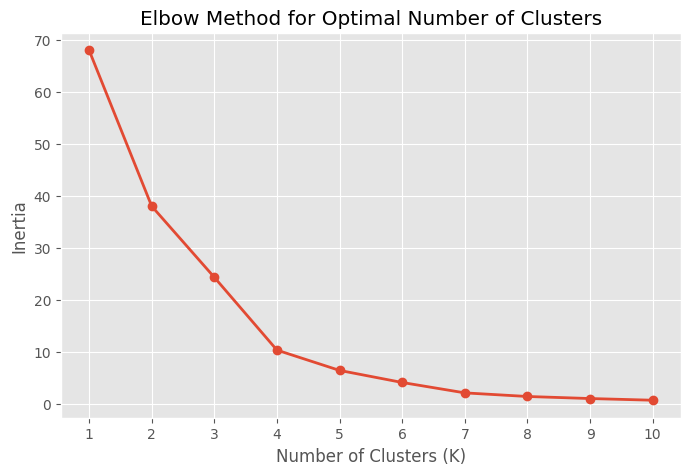

In [251]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia values for different K
inertia = []

# Try cluster values from 1 to 10
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train model
    kmeans.fit(scaled_df)

    # Save inertia value
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)

plt.show()

# Selecting the Optimal Number of Clusters

From the Elbow Plot, choose the value of K where the curve starts to flatten.

In my dataset, the elbow point is approximately **K = 4**.

This value provides a good balance between model complexity and clustering performance.

In [254]:
# Select the optimal number of clusters
optimal_k = 4

print("Optimal Number of Clusters:", optimal_k)

Optimal Number of Clusters: 4


# K-Means Clustering

After selecting the optimal number of clusters using the Elbow Method, we train the K-Means model.

Each product sub-category is assigned to a cluster based on its sales characteristics.

Products in the same cluster have similar sales patterns.

In [257]:
# Create and train the K-Means model

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit the model on standardized features
kmeans.fit(scaled_df)

# Assign cluster labels
cluster_data["Cluster"] = kmeans.labels_

# Display first few rows
cluster_data.head()

,Sub-Category,Total Sales,Average Growth,Sales Volatility,Average Order Value,Cluster
0,Accessories,164186.7000,0.376381,2579.994809,233.884188,2
1,Appliances,104618.4030,0.399276,1821.621539,235.627034,1
2,Art,26705.4100,0.166056,330.488343,37.090847,1
3,Binders,200028.7850,0.218736,3848.223648,154.940964,2
4,Bookcases,113813.1987,0.238065,2220.405080,512.672066,1


# Number of Products in Each Cluster

Now we check how many product sub-categories belong to each cluster.

This helps us understand the distribution of products.

In [260]:
# Count the number of sub-categories in each cluster

cluster_counts = cluster_data["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    2
1    8
2    6
3    1
Name: count, dtype: int64


# Cluster-wise Product List

Let's see which product sub-categories belong to each cluster.

In [263]:
# Display product sub-categories in each cluster

for cluster in sorted(cluster_data["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 30)

    products = cluster_data.loc[
        cluster_data["Cluster"] == cluster,
        "Sub-Category"
    ]

    print(products.to_string(index=False))


Cluster 0
------------------------------
 Copiers
Machines

Cluster 1
------------------------------
 Appliances
        Art
  Bookcases
  Envelopes
  Fasteners
Furnishings
     Labels
      Paper

Cluster 2
------------------------------
Accessories
    Binders
     Chairs
     Phones
    Storage
     Tables

Cluster 3
------------------------------
Supplies


# Observations

- Every product sub-category has been assigned to one cluster.
- Products in the same cluster have similar sales behaviour.
- Different clusters represent different demand patterns.
- These clusters will help us understand which products perform similarly.
- In the next step, PCA will be used to visualize these clusters in two dimensions.

# PCA Visualization

After creating the clusters, it is difficult to visualize data because it has multiple features.

Principal Component Analysis (PCA) is used to reduce the data to two dimensions while preserving most of the important information.

This makes it easier to visualize the clusters.

In [267]:
from sklearn.decomposition import PCA

# Create PCA model with 2 principal components
pca = PCA(n_components=2)

# Transform the standardized data
pca_features = pca.fit_transform(scaled_df)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(
    pca_features,
    columns=["Principal Component 1", "Principal Component 2"]
)

# Add cluster labels
pca_df["Cluster"] = cluster_data["Cluster"]

# Display first few rows
pca_df.head()

,Principal Component 1,Principal Component 2,Cluster
0,0.034154,-0.117122,2
1,-0.568080,0.135797,1
2,-1.734355,-0.168481,1
3,0.621902,-0.574407,2
4,-0.123767,-0.073649,1


# Visualizing the Clusters

The scatter plot below shows how the product sub-categories are grouped into different clusters using the first two principal components.

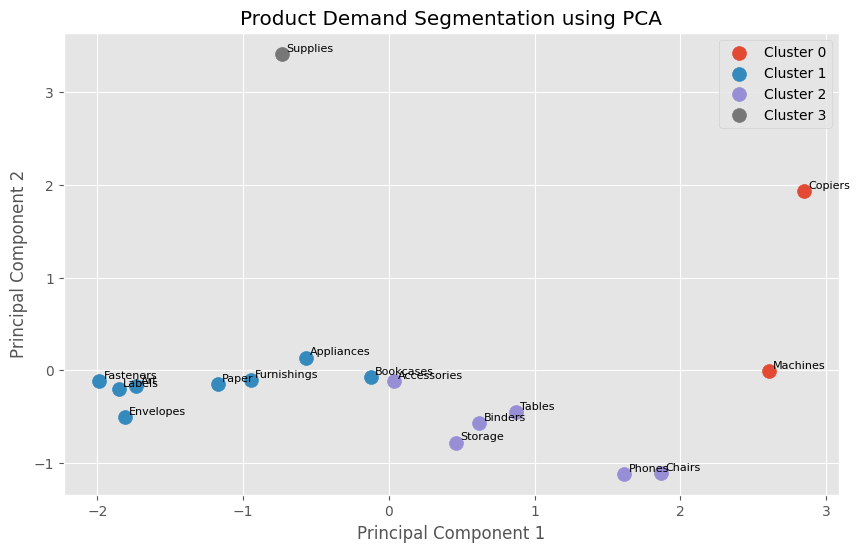

In [270]:
plt.figure(figsize=(10, 6))

# Plot each cluster separately
for cluster in sorted(pca_df["Cluster"].unique()):
    
    cluster_points = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        cluster_points["Principal Component 1"],
        cluster_points["Principal Component 2"],
        s=100,
        label=f"Cluster {cluster}"
    )

# Add product names to each point
for i in range(len(pca_df)):
    plt.text(
        pca_df.loc[i, "Principal Component 1"] + 0.03,
        pca_df.loc[i, "Principal Component 2"] + 0.03,
        cluster_data.loc[i, "Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

# Observations

- PCA reduced the multi-dimensional data into two dimensions.
- Products belonging to the same cluster are located close to each other.
- Different colours represent different clusters.
- Well-separated clusters indicate that K-Means has grouped products effectively.
- This visualization makes it easier to understand the demand patterns of different product sub-categories.

# Cluster Interpretation

Now that each product sub-category has been assigned to a cluster, we can analyze the characteristics of each cluster.

The average values of the features are calculated to understand the demand pattern of products in each cluster.

In [274]:
# Calculate the average values for each cluster

cluster_summary = (
    cluster_data.groupby("Cluster")[
        [
            "Total Sales",
            "Average Growth",
            "Sales Volatility",
            "Average Order Value"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,Total Sales,Average Growth,Sales Volatility,Average Order Value
Cluster,,,,
0,167743.36,0.46,5552.16,1952.76
1,55331.88,0.20,907.22,134.08
2,239495.78,0.18,3489.06,387.67
3,46420.31,1.93,2025.09,256.47


# Assign Business Labels to Clusters

Based on the summary statistics, assign meaningful names to each cluster.

These labels may differ depending on your clustering results.

In [277]:
# Change these labels if your cluster characteristics are different

cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Moderate Demand"
}

# Add cluster names
cluster_data["Cluster Name"] = cluster_data["Cluster"].map(cluster_labels)

# Display updated dataset
cluster_data.head()

,Sub-Category,Total Sales,Average Growth,Sales Volatility,Average Order Value,Cluster,Cluster Name
0,Accessories,164186.7000,0.376381,2579.994809,233.884188,2,Growing Demand
1,Appliances,104618.4030,0.399276,1821.621539,235.627034,1,"Low Volume, High Volatility"
2,Art,26705.4100,0.166056,330.488343,37.090847,1,"Low Volume, High Volatility"
3,Binders,200028.7850,0.218736,3848.223648,154.940964,2,Growing Demand
4,Bookcases,113813.1987,0.238065,2220.405080,512.672066,1,"Low Volume, High Volatility"


# Cluster Summary with Labels

In [280]:
# Add labels to the summary table

cluster_summary = cluster_summary.reset_index()

cluster_summary["Cluster Name"] = cluster_summary["Cluster"].map(cluster_labels)

cluster_summary

,Cluster,Total Sales,Average Growth,Sales Volatility,Average Order Value,Cluster Name
0,0,167743.36,0.46,5552.16,1952.76,"High Volume, Stable Demand"
1,1,55331.88,0.20,907.22,134.08,"Low Volume, High Volatility"
2,2,239495.78,0.18,3489.06,387.67,Growing Demand
3,3,46420.31,1.93,2025.09,256.47,Moderate Demand


# Business Recommendations

Based on the characteristics of each cluster, suitable inventory and business strategies can be suggested.

In [283]:
# Recommendations for each cluster

recommendations = {
    "High Volume, Stable Demand":
        "Increase inventory because demand is consistently high.",

    "Low Volume, High Volatility":
        "Maintain limited stock and monitor demand regularly.",

    "Growing Demand":
        "Increase inventory gradually and focus on marketing.",

    "Moderate Demand":
        "Maintain normal inventory and review sales periodically."
}

# Map recommendations
cluster_summary["Recommendation"] = cluster_summary["Cluster Name"].map(recommendations)

cluster_summary

,Cluster,Total Sales,Average Growth,Sales Volatility,Average Order Value,Cluster Name,Recommendation
0,0,167743.36,0.46,5552.16,1952.76,"High Volume, Stable Demand",Increase inventory because demand is consisten...
1,1,55331.88,0.20,907.22,134.08,"Low Volume, High Volatility",Maintain limited stock and monitor demand regu...
2,2,239495.78,0.18,3489.06,387.67,Growing Demand,Increase inventory gradually and focus on mark...
3,3,46420.31,1.93,2025.09,256.47,Moderate Demand,Maintain normal inventory and review sales per...


# Final Clustered Dataset

In [286]:
# Display the final clustered dataset

cluster_data.sort_values("Cluster")

,Sub-Category,Total Sales,Average Growth,Sales Volatility,Average Order Value,Cluster,Cluster Name
6,Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,"High Volume, Stable Demand"
11,Machines,189238.6310,0.080060,5603.554747,1689.630634,0,"High Volume, Stable Demand"
8,Fasteners,3001.9600,0.157034,48.742229,14.160189,1,"Low Volume, High Volatility"
1,Appliances,104618.4030,0.399276,1821.621539,235.627034,1,"Low Volume, High Volatility"
2,Art,26705.4100,0.166056,330.488343,37.090847,1,"Low Volume, High Volatility"
4,Bookcases,113813.1987,0.238065,2220.405080,512.672066,1,"Low Volume, High Volatility"
7,Envelopes,16128.0460,-0.027666,228.218688,66.370560,1,"Low Volume, High Volatility"
12,Paper,76828.3040,0.254131,1024.824982,66.060451,1,"Low Volume, High Volatility"
9,Furnishings,89212.0180,0.287889,1360.017867,104.341542,1,"Low Volume, High Volatility"
10,Labels,12347.7260,0.121927,223.471218,36.316841,1,"Low Volume, High Volatility"


# Observations

- Products were successfully grouped using K-Means clustering.
- Each cluster contains products with similar sales characteristics.
- High-volume products contribute significantly to overall sales.
- Some products have stable demand, while others show large fluctuations.
- Growing products indicate increasing customer demand.
- Products with high volatility require regular monitoring.
- Average Order Value helps identify products with higher customer spending.
- PCA visualization clearly showed the separation between clusters.
- The clustering results can help improve inventory planning and demand forecasting.
- Overall, clustering provides useful insights for business decision-making.

# Conclusion

In this task, K-Means clustering was applied to segment product sub-categories based on Total Sales, Average Growth, Sales Volatility, and Average Order Value.

Before clustering, the features were standardized to ensure equal importance during model training. The Elbow Method was used to determine the optimal number of clusters, and PCA was applied to visualize the clusters in two dimensions.

The analysis showed that different product sub-categories have different demand patterns. Some products have consistently high sales, some are growing rapidly, while others show higher fluctuations in demand.

Business recommendations were provided for each cluster to support better inventory management, demand planning, and marketing strategies.

Overall, product demand segmentation helps businesses understand customer purchasing patterns and make better decisions related to stock management, sales planning, and resource allocation.